# Distribution

Generate files of multiple decoders of the same code and noise.

In [1]:
unit_shots: int = 100_000
shots: int = 300_000

code: str = "css_rsc(d=7)"
noise: str = "depolarize(p=0.01)"
decoders: list[str] = [
    "mwpf(c=0)",
    "mwpf(c=50)",
    "mwpf(c=200)",
    # "fb",
    # "fb(max_tree_size=0)",
]

slurm_maximum_jobs: int = 50  # start with a smaller number of workers to avoid resource waste
slurm_cores_per_node: int = 10  # (slurm_maximum_jobs // slurm_cores_per_node) should not exceed 200
slurm_mem_per_job: int = 4  # 4GB per job
slurm_extra: dict = dict(
    walltime = "1-00:00:00",  # adaptively shutdown if no more jobs
    queue = "scavenge",  # use with caution: dask does not seem to handle scavenge workers well
    job_extra_directives = ["--requeue"],  # use with scavenge partition will help spawn scavenged jobs
)

local_maximum_jobs: int = None

gen_json_filename: str = None
trace_json_filename: str = None

samples_dir: str = "./tmp_samples"
trace_dir: str = "./tmp_trace"

In [2]:
# Parameters
code = "css_rsc(d@7)"
noise = "depolarize(p@0.01)"
decoders = ["mwpf(c@0)", "mwpf(c@15)", "mwpf(c@200)"]
gen_json_filename = "capacity-rsc-d7.gen.css-rsc-d-7.depolarize-p-0-01.json"
trace_json_filename = "capacity-rsc-d7.trace.css-rsc-d-7.depolarize-p-0-01.json"
samples_dir = (
    "/Users/wuyue/Documents/GitHub/PaperMWPFEvaluation/distribution/tmp_samples"
)
trace_dir = "/Users/wuyue/Documents/GitHub/PaperMWPFEvaluation/distribution/tmp_trace"
local_maximum_jobs = 6
unit_shots = 10000000
shots = 10000000


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
code = code.replace("@", "=")
noise = noise.replace("@", "=")
decoders = [decoder.replace("@", "=").replace(";", ",") for decoder in decoders]

from qec_lego_bench.notebooks.trace_distribution import *

if gen_json_filename is None:
    gen_json_filename = default_gen_json_filename(code=code, noise=noise)
print("saving gen samples results to:", gen_json_filename)
if trace_json_filename is None:
    trace_json_filename = default_trace_json_filename(code=code, noise=noise)
print("saving trace results to:", trace_json_filename)


saving gen samples results to: capacity-rsc-d7.gen.css-rsc-d-7.depolarize-p-0-01.json
saving trace results to: capacity-rsc-d7.trace.css-rsc-d-7.depolarize-p-0-01.json


In [5]:

from qec_lego_bench.notebooks.trace_distribution import *

# check if any decoder requires decomposing errors, if so, use that decoder
representative_decoder: str = "none"
for decoder in decoders:
    if DecoderCli(decoder).decompose_errors:
        representative_decoder = decoder
        break

generate_sample_function = TraceDistributionSampleGenerationMonteCarloFunction(
    unit_shots=unit_shots,
    samples_dir=samples_dir,
)
# generate_sample_function(1, code=code, noise=noise, decoder=representative_decoder, idx=0)

repeats = math.ceil(shots / unit_shots)
jobs = [
    MonteCarloJob(
        code=code,
        noise=noise,
        decoder=representative_decoder,
        idx=i,
    )
    for i in range(repeats)
]

In [6]:
min_shots_submitter = MinShotsSubmitter(shots=1)

def submitter(executor: MonteCarloJobExecutor) -> list[tuple[MonteCarloJob, int]]:
    return min_shots_submitter(executor)

In [7]:
# remove json file to force restart since each function job has the result detection logic
if not os.path.exists(samples_dir):
    if os.path.exists(gen_json_filename):
        os.remove(gen_json_filename)

    # Also print version data to the json file
    import stim, qec_lego_bench, sinter

    print("stim.__version__:", stim.__version__)
    print("qec_lego_bench.__version__:", qec_lego_bench.__version__)
    print("sinter.__version__:", sinter.__version__)

    with open(gen_json_filename, "w") as f:
        json.dump(
            {
                "_version": {
                    "stim": stim.__version__,
                    "qec_lego_bench": qec_lego_bench.__version__,
                    "sinter": sinter.__version__,
                },
            },
            f,
        )

if not os.path.exists(samples_dir):
    os.makedirs(samples_dir)

In [8]:
config = MonteCarloExecutorConfig()
config.max_submitted_job = max(config.max_submitted_job, 3 * slurm_maximum_jobs)
executor = MonteCarloJobExecutor(
    generate_sample_function,
    jobs,
    config=config,
    filename=gen_json_filename,
    result_type=LogicalErrorResult,
)

client_connector = SlurmClientConnector(
    slurm_maximum_jobs=slurm_maximum_jobs,
    slurm_cores_per_node=slurm_cores_per_node,
    slurm_mem_per_job=slurm_mem_per_job,
    slurm_extra=slurm_extra,
    local_maximum_jobs=local_maximum_jobs,
)

In [9]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()

def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
)

,Status,JobKey,Job,Finished,Pending,Submitted,0 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,finished,914e65,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=none, idx=0)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,2.1s (0.0min),0,0,0,0.0(0)


''

# We then evaluate individual decoders

In [10]:
# Also print version data to the json file
import stim, qec_lego_bench, sinter

print("stim.__version__:", stim.__version__)
print("qec_lego_bench.__version__:", qec_lego_bench.__version__)
print("sinter.__version__:", sinter.__version__)

# remove json file to force restart since each function job has the result detection logic
if not os.path.exists(trace_dir):
    if os.path.exists(trace_json_filename):
        os.remove(trace_json_filename)

    with open(trace_json_filename, "w") as f:
        json.dump(
            {
                "_version": {
                    "stim": stim.__version__,
                    "qec_lego_bench": qec_lego_bench.__version__,
                    "sinter": sinter.__version__,
                },
            },
            f,
        )

if not os.path.exists(trace_dir):
    os.makedirs(trace_dir)

stim.__version__: 1.15.dev0
qec_lego_bench.__version__: 0.0.4.post1.dev7+gc78c55b.d20250222
sinter.__version__: 1.15.dev0


In [11]:

trace_function = TraceDistributionMonteCarloFunction(
    unit_shots=unit_shots,
    samples_dir=samples_dir,
    trace_dir=trace_dir,
)
# trace_function(1, code=code, noise=noise, decoder=decoders[0], idx=0)

trace_jobs = [
    MonteCarloJob(
        code=code,
        noise=noise,
        decoder=decoder,
        idx=i,
    )
    for i in range(repeats)
    for decoder in decoders
]

In [12]:
trace_executor = MonteCarloJobExecutor(
    trace_function,
    trace_jobs,
    config=config,
    filename=trace_json_filename,
    result_type=LogicalErrorResult,
)

In [13]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()

def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


trace_executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
)

,Status,JobKey,Job,Finished,Pending,Submitted,0 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,finished,a73fa0,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=0), idx=0)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,245.8s (4.1min),0,0,0,0.0(0)
1,finished,a61b6d,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=15), idx=0)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,278.5s (4.6min),0,0,0,0.0(0)
2,finished,3ebd6a,"Job(code=css_rsc(d=7), noise=depolarize(p=0.01), decoder=mwpf(c=200), idx=0)",10000000 (100%),0 (0%),0 (0%),0 (0%),10000000,303.7s (5.1min),0,0,0,0.0(0)


''

# Plot the time distribution of individual decoders

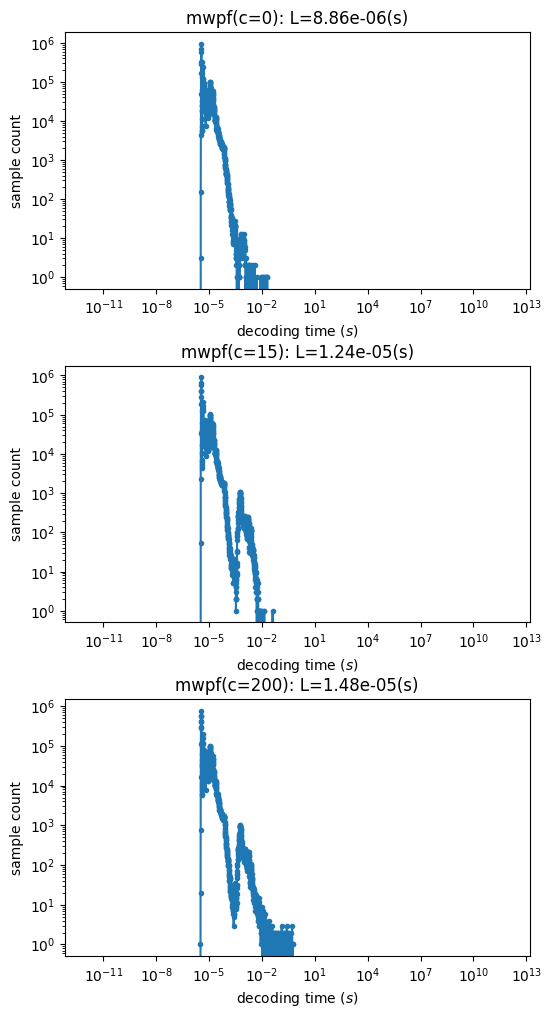

In [14]:
plotter = TraceTimeDistributionPlotter(
    unit_shots=unit_shots,
    repeats=repeats,
    trace_dir=trace_dir,
    code=code,
    noise=noise,
)
plotter(decoders=decoders)